Fine-tune a pretrained transformer model such as BERT or DistilBERT to perform sentiment analysis on text data.<br>
The model should classify text into:<br>
1. Positive
2. Negative
3. Neutral (optional: multi-class support)


In [135]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

#core libraries
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

#data processing and evaluation libraries
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix

#transformers libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [136]:
# ============================================================
# CELL 2: CHECK GPU / CUDA AVAILABILITY
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device being used:", device)

if device == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will run on CPU.")

Device being used: cuda
GPU Name: NVIDIA GeForce GTX 1050 Ti with Max-Q Design


First 5 rows of dataset:
                                                text sentiment
0                   need to leave now.. tweet laters   neutral
1   I don`t get as much time here either. It`s go...  negative
2  Jeff can`t get his visa in time to come visit ...  negative
3  Great for organization. I love the color schem...  positive
4                            First time to Twitter..   neutral

Label Distribution:
sentiment
neutral     14425
positive    12649
negative    11074
Name: count, dtype: int64


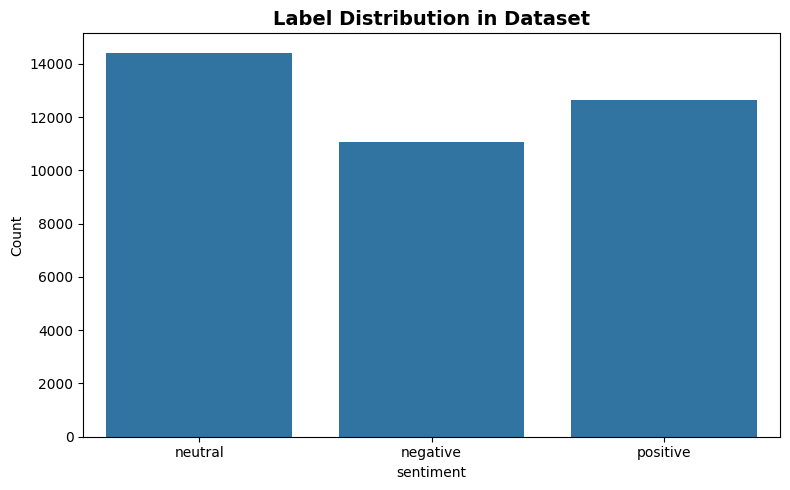

In [137]:
# ============================================================
# CELL 3: LOAD AND EXPLORE THE DATASET
# ============================================================

# Function to load and explore the dataset
def load_dataset(file_path):
    """
    Load and perform initial exploration of the dataset
    """
    # upload the dataset
    df = pd.read_csv(file_path)
    
    #check the first few rows of the dataset
    print("First 5 rows of dataset:")
    print(df.head())
    
    # check the label distribution
    print("\nLabel Distribution:")
    print(df['sentiment'].value_counts())
    
    # plot the label distribution with default colors
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment', data=df)
    plt.title('Label Distribution in Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('sentiment')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/label_distribution.png')
    plt.show()
    
    return df

# Load dataset
df = load_dataset('dataset/sentiment_dataset.csv')

Cleaned dataset shape: (38147, 2)
sentiment
neutral     14424
positive    12649
negative    11074
Name: count, dtype: int64


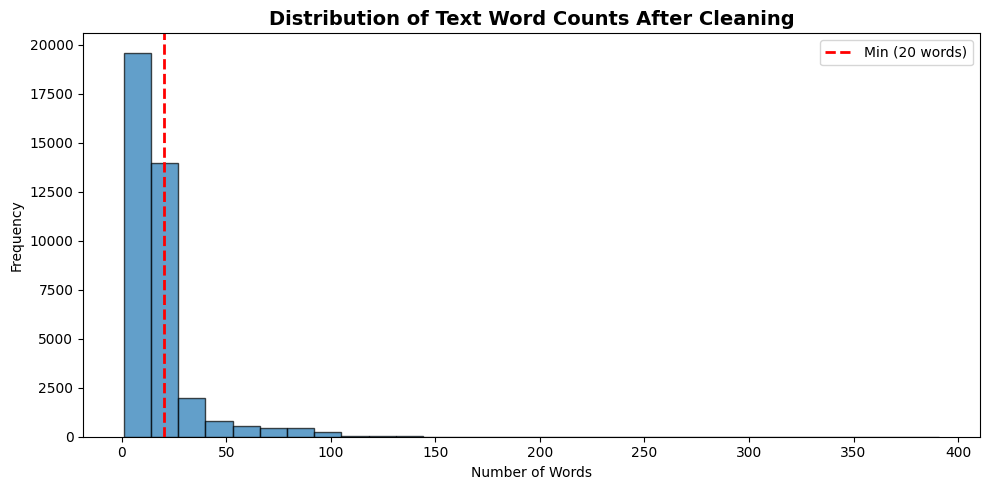

In [138]:
# ============================================================
# CELL 4: DATA CLEANING
# ============================================================

# perform data cleaning before preprocessing and training the models
def clean_dataset(df):
    """
    Clean the dataset by handling missing values, duplicates, and filtering reviews
    """

    # Keep only required columns
    df = df[["text", "sentiment"]]

    # Remove missing values
    df = df.dropna()

    # Convert text and labels to string
    df["text"] = df["text"].astype(str)
    df["sentiment"] = df["sentiment"].astype(str)

    # Convert labels to lowercase
    df["sentiment"] = df["sentiment"].str.lower().str.strip()

    # Keep only valid sentiment labels
    valid_labels = ["positive", "negative", "neutral"]
    df = df[df["sentiment"].isin(valid_labels)]

    # Remove duplicate reviews
    df = df.drop_duplicates(subset=["text"])

    print("Cleaned dataset shape:", df.shape)
    print(df["sentiment"].value_counts())
    
    # Visualize Text length distribution after cleaning
    plt.figure(figsize=(10, 5))
    plt.hist(df['text'].apply(lambda x: len(str(x).split())), bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Min (20 words)')
    plt.title('Distribution of Text Word Counts After Cleaning', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/Text_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df

# Clean dataset (before preprocessing)
df = clean_dataset(df)

In [139]:
# ============================================================
# CELL 5: ENCODE SENTIMENT LABELS
# ============================================================

label_encoder = LabelEncoder()

df["sentiment_encoded"] = label_encoder.fit_transform(df["sentiment"])

label_names = list(label_encoder.classes_)

print("Label mapping:")
for index, label in enumerate(label_names):
    print(index, "->", label)

Label mapping:
0 -> negative
1 -> neutral
2 -> positive


In [140]:
# ============================================================
# CELL 6: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment_encoded"]
)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (30517, 3)
Testing data shape: (7630, 3)


In [141]:
# ============================================================
# CELL 7: BUILD HUGGING FACE DATASETS
# ============================================================

# Convert pandas DataFrames to Hugging Face Datasets, which are more efficient for training transformer models
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'sentiment', 'sentiment_encoded', '__index_level_0__'],
    num_rows: 30517
})
Dataset({
    features: ['text', 'sentiment', 'sentiment_encoded', '__index_level_0__'],
    num_rows: 7630
})


In [ ]:
# ============================================================
# CELL 8: TOKENIZER & TOKENIZATION
# ============================================================

# Load the DistilBERT tokenizer and tokenize the text data
model_name = "distilbert-base-uncased"

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)  #change local_files = false , for the first time to dowqnload the tokenizer files from Hugging Face model hub.

# Define a function to tokenize the text data in batches
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


# Tokenize the training and testing datasets
train_dataset = train_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

# Rename the encoded sentiment column to "labels" as expected by the Trainer API
train_dataset = train_dataset.rename_column("sentiment_encoded", "labels")
test_dataset = test_dataset.rename_column("sentiment_encoded", "labels")

# Remove the original text column as it's no longer needed after tokenization
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# Set the format of the datasets to PyTorch tensors for compatibility with the Trainer API
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Tokenization completed.")
print("Train columns:", train_dataset.column_names)
print("Test columns:", test_dataset.column_names)














Map: 100%|██████████| 30517/30517 [00:01<00:00, 19224.50 examples/s]




Map: 100%|██████████| 7630/7630 [00:00<00:00, 17171.69 examples/s]

Tokenization completed.
Train columns: ['sentiment', 'labels', '__index_level_0__', 'input_ids', 'attention_mask']
Test columns: ['sentiment', 'labels', '__index_level_0__', 'input_ids', 'attention_mask']


In [143]:
# ============================================================
# CELL 9: MODEL INITIALIZATION
# ============================================================

# Load the pre-trained DistilBERT model for sequence classification and move it to the appropriate device (GPU or CPU)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label={i: label for i, label in enumerate(label_names)},
    label2id={label: i for i, label in enumerate(label_names)}
)

# Move the model to the appropriate device (GPU or CPU)
model.to(device)

print("Model loaded:", model_name)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-uncased


In [144]:
# ============================================================
# CELL 10: TRAINER SETUP
# ============================================================

# Define the compute_metrics function to calculate accuracy, precision, recall, and F1-score during evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Set up the training arguments for the Trainer, including evaluation strategy, learning rate, batch size, number of epochs, and other parameters
training_args = TrainingArguments(
    output_dir="models/training_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# Initialize the Trainer with the model, training arguments, datasets, and compute_metrics function
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [145]:
# ============================================================
# CELL 11: TRAIN & EVALUATE
# ============================================================

# Train the model using the Trainer API and evaluate its performance on the test set
trainer.train()

# Evaluate the model on the test set and print the metrics
metrics = trainer.evaluate()

print(metrics)

  1%|          | 50/5724 [00:24<45:14,  2.09it/s] 

{'loss': 1.0715, 'grad_norm': 3.505293607711792, 'learning_rate': 1.9825296995108317e-05, 'epoch': 0.03}


  2%|▏         | 100/5724 [00:48<45:50,  2.04it/s]

{'loss': 0.8147, 'grad_norm': 4.903485298156738, 'learning_rate': 1.9650593990216632e-05, 'epoch': 0.05}


  3%|▎         | 150/5724 [01:12<45:01,  2.06it/s]

...

{'eval_loss': 0.644672691822052, 'eval_accuracy': 0.7656618610747051, 'eval_precision': 0.7667932899191682, 'eval_recall': 0.7656618610747051, 'eval_f1': 0.7661331420367811, 'eval_runtime': 80.4449, 'eval_samples_per_second': 94.848, 'eval_steps_per_second': 5.93, 'epoch': 3.0}


100%|██████████| 5724/5724 [50:05<00:00,  1.90it/s]


{'train_runtime': 3005.2362, 'train_samples_per_second': 30.464, 'train_steps_per_second': 1.905, 'train_loss': 0.4910417531104791, 'epoch': 3.0}


100%|██████████| 477/477 [01:20<00:00,  5.96it/s]

{'eval_loss': 0.644672691822052, 'eval_accuracy': 0.7656618610747051, 'eval_precision': 0.7667932899191682, 'eval_recall': 0.7656618610747051, 'eval_f1': 0.7661331420367811, 'eval_runtime': 80.1817, 'eval_samples_per_second': 95.159, 'eval_steps_per_second': 5.949, 'epoch': 3.0}


100%|██████████| 477/477 [01:19<00:00,  5.98it/s]


              precision    recall  f1-score   support

    negative       0.78      0.76      0.77      2215
     neutral       0.70      0.73      0.71      2885
    positive       0.83      0.81      0.82      2530

    accuracy                           0.77      7630
   macro avg       0.77      0.77      0.77      7630
weighted avg       0.77      0.77      0.77      7630



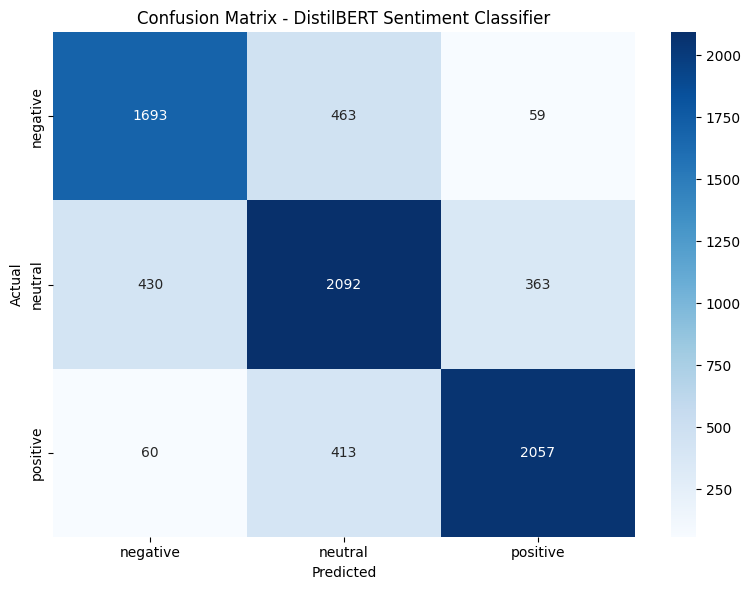

In [146]:
# ============================================================
# CELL 12: CLASSIFICATION REPORT & CONFUSION MATRIX
# ============================================================

# Generate predictions on the test set and create a classification report and confusion matrix
pred_output = trainer.predict(test_dataset)

# Extract the true labels and predicted labels from the prediction output
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

# Generate a classification report using scikit-learn's classification_report function, 
# which includes precision, recall, F1-score, and support for each class
report = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    zero_division=0
)

print(report)

with open("figures/classification_report.txt", "w", encoding="utf-8") as file:
    file.write(report)

# Generate a confusion matrix using scikit-learn's confusion_matrix function, 
# which shows the counts of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT Sentiment Classifier")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

In [147]:
# ============================================================
# CELL 13: SAVE & RELOAD MODEL
# ============================================================

# Save the trained model and tokenizer to the "models/distilbert_sentiment_model" directory, 
# and then reload them to verify that they were saved correctly
trainer.save_model("models/distilbert_sentiment_model")
tokenizer.save_pretrained("models/distilbert_sentiment_model")

# Reload the model and tokenizer from the saved directory to verify that they were saved correctly
loaded_tokenizer = AutoTokenizer.from_pretrained("models/distilbert_sentiment_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("models/distilbert_sentiment_model")

# Move the loaded model to the appropriate device (GPU or CPU) and set it to evaluation mode
loaded_model.to(device)
loaded_model.eval()

print("Model saved and reloaded successfully.")

Model saved and reloaded successfully.


In [148]:
# ============================================================
# CELL 14: INFERENCE FUNCTION
# ============================================================

# Define a function to predict the sentiment of a given text input using the loaded model and tokenizer
def predict_sentiment(text):
    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

# Move the input tensors to the appropriate device (GPU or CPU) before passing them to the model for inference
    inputs = {key: value.to(device) for key, value in inputs.items()}

#
    with torch.no_grad():
        outputs = loaded_model(**inputs)

# Apply softmax to the model's output logits to get probabilities for each class, and then determine the predicted class with the highest probability
    probabilities = torch.softmax(outputs.logits, dim=1)[0]
    predicted_id = torch.argmax(probabilities).item()

    return {
        "text": text,
        "sentiment": loaded_model.config.id2label[predicted_id],
        "confidence": round(probabilities[predicted_id].item() * 100, 2)
    }

In [149]:
# ============================================================
# CELL 15: TEST CUSTOM REVIEWS
# ============================================================

# Test the sentiment prediction function with some custom reviews to see how well the model performs on new, unseen data
test_reviews = [
    "I really love this product, it works perfectly.",
    "This is the worst experience I have ever had.",
    "The service was okay, nothing special.",
    "I am not sure how I feel about this.",
    "Excellent quality and very fast delivery."
]

# Predict the sentiment for each review in the test_reviews list and print the results
for review in test_reviews:
    print(predict_sentiment(review))

{'text': 'I really love this product, it works perfectly.', 'sentiment': 'positive', 'confidence': 98.96}
{'text': 'This is the worst experience I have ever had.', 'sentiment': 'negative', 'confidence': 98.91}
{'text': 'The service was okay, nothing special.', 'sentiment': 'neutral', 'confidence': 66.77}
{'text': 'I am not sure how I feel about this.', 'sentiment': 'negative', 'confidence': 89.48}
{'text': 'Excellent quality and very fast delivery.', 'sentiment': 'positive', 'confidence': 97.49}
